**1. Exploratory Data Analysis and Data Understanding**

Import libraries & load data

In [103]:
from google.colab import files

uploaded = files.upload()


Saving loan_data.csv to loan_data (2).csv


In [104]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_class_weight


## 1. Dataset Selection & Understanding

### Dataset
This project uses the **Loan Approval Classification Dataset** (synthetic loan approval / credit risk-style dataset).

### (a) Created by + when
The dataset is published on Kaggle by **Ta-wei Lo (username: taweilo)**.  
It is described as a **synthetic dataset inspired by an original credit risk dataset** and enriched with extra variables.

### (b) How/where accessed
The dataset was accessed from **Kaggle** and downloaded as a CSV file, then loaded into a pandas DataFrame using `pd.read_csv()` in this notebook.

### (c) UNSDG alignment (justification)
This dataset aligns with:
- **SDG 1 (No Poverty)** and **SDG 8 (Decent Work & Economic Growth)** because access to loans/credit can support education, health, business, and employment opportunities, while better credit decisions reduce financial risk and improve fairness in lending.

### (d) Attributes (features) — Data dictionary
- `person_age`: Applicant age
- `person_gender`: Applicant gender
- `person_education`: Education level
- `person_income`: Annual income
- `person_emp_exp`: Employment experience (years)
- `person_home_ownership`: Housing status (e.g., RENT/OWN/MORTGAGE)
- `loan_amnt`: Requested loan amount
- `loan_intent`: Purpose of loan (e.g., EDUCATION, MEDICAL, PERSONAL, etc.)
- `loan_int_rate`: Interest rate
- `loan_percent_income`: Loan amount as a fraction of income
- `cb_person_cred_hist_length`: Credit history length
- `credit_score`: Credit score
- `previous_loan_defaults_on_file`: Whether applicant has previous defaults on record
- `loan_status` (Target): 1 = Approved, 0 = Rejected

### Questions this dataset can answer
1. Which features (income, credit score, intent, etc.) most influence loan approval?
2. Do approval rates differ by loan intent (EDUCATION vs MEDICAL vs PERSONAL)?
3. How do credit history length and previous defaults affect approval probability?


In [105]:
# Load the dataset
df = pd.read_csv("loan_data.csv")

# Check if it loaded correctly
df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


Basic inspection (inspect & preview):

In [106]:
print("Dataset shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.head()


Dataset shape (rows, columns): (45000, 14)

Column names:
['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


List & describe ALL attributes (features):

In [107]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [108]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isna().sum(),
    "Unique Values": df.nunique()
})

summary


,Data Type,Missing Values,Unique Values
person_age,int64,0,60
person_gender,object,0,2
person_education,object,0,5
person_income,int64,0,33989
person_emp_exp,int64,0,63
person_home_ownership,object,0,4
loan_amnt,int64,0,4483
loan_intent,object,0,6
loan_int_rate,float64,0,1302
loan_percent_income,float64,0,64


Identify target variable + imbalance

In [109]:
TARGET = "loan_status"

df[TARGET].value_counts()


,count
loan_status,
0,35000
1,10000


In [110]:
df[TARGET].value_counts(normalize=True) * 100


,proportion
loan_status,
0,77.777778
1,22.222222


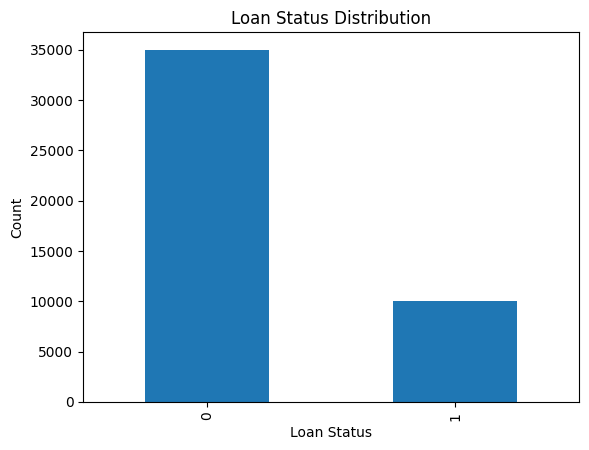

In [111]:
df[TARGET].value_counts().plot(kind="bar")
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()


**Insight:**  
The class distribution shows that approved loans are significantly fewer than rejected loans, indicating a class imbalance problem. Because of this imbalance, accuracy alone is not a reliable metric, and F1-score, precision, and recall are more appropriate for evaluating model performance.


Check dataset quality (missing, duplicates, noise)

In [112]:
print("Total missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Total missing values: 0
Duplicate rows: 0


Summary statistics (summarize)

In [113]:
df.describe()


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


Separate numerical & categorical columns:

Column types:

In [114]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numerical columns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_status']


Visualize numerical data:

Histograms:

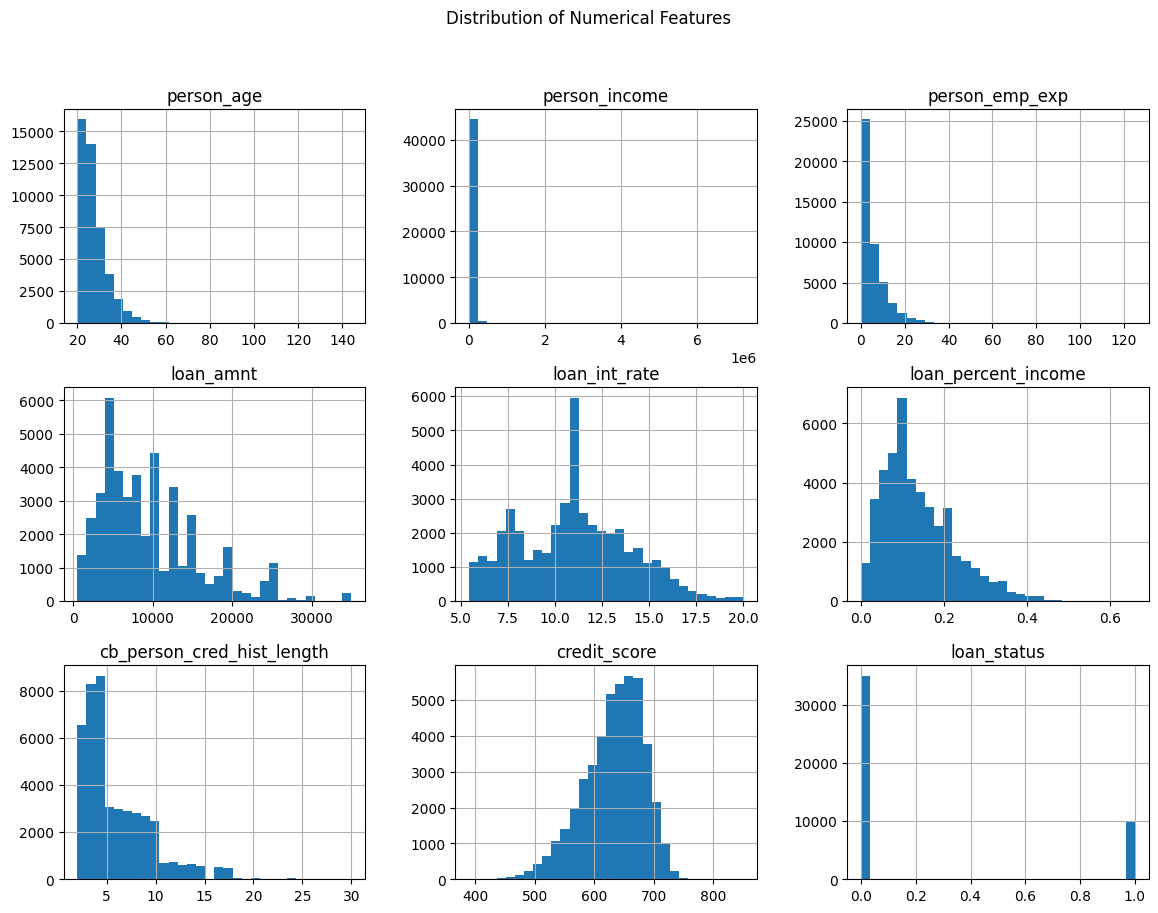

In [115]:
df[numerical_cols].hist(figsize=(14,10), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()



**Insight:**  
The numerical features show varied distributions across the dataset. Features such as *person_age*, *person_income*, *person_emp_exp*, *loan_amnt*, *loan_percent_income*, and *cb_person_cred_hist_length* are right-skewed, indicating the presence of outliers and a wide range of applicant financial profiles. In contrast, *credit_score* follows an approximately normal distribution, suggesting a stable and well-distributed feature. These observations justify the use of feature scaling and robust evaluation metrics, as well as tree-based models that are less sensitive to skewed data.


Boxplots (to show noise/outliers)

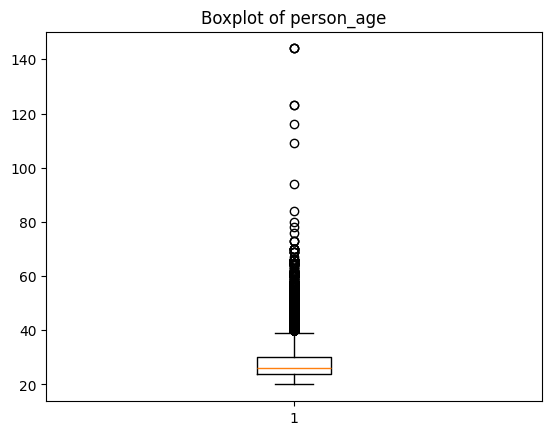

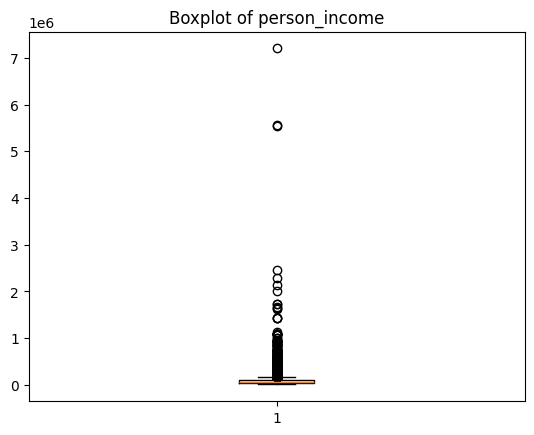

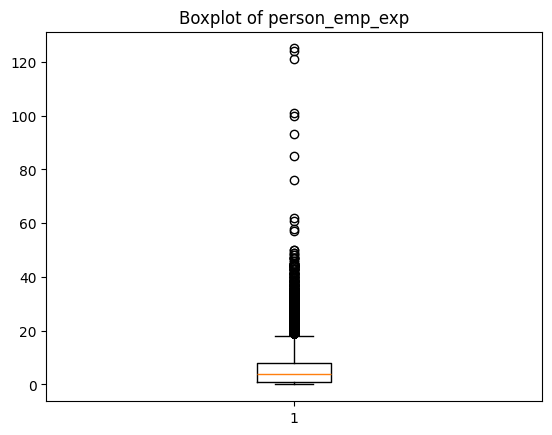

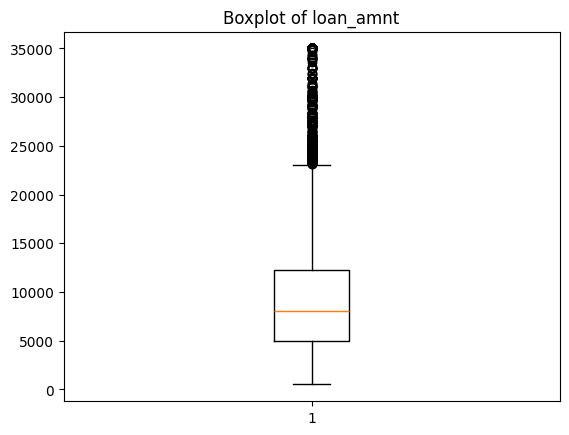

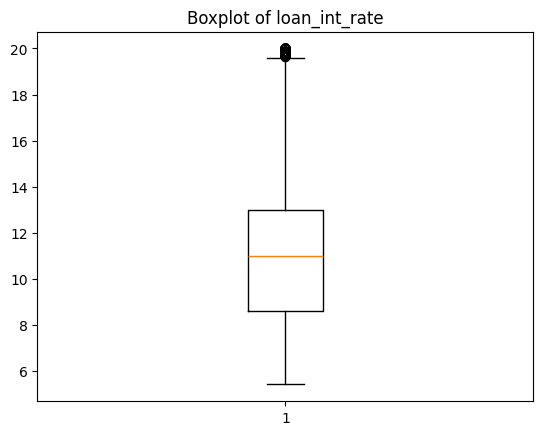

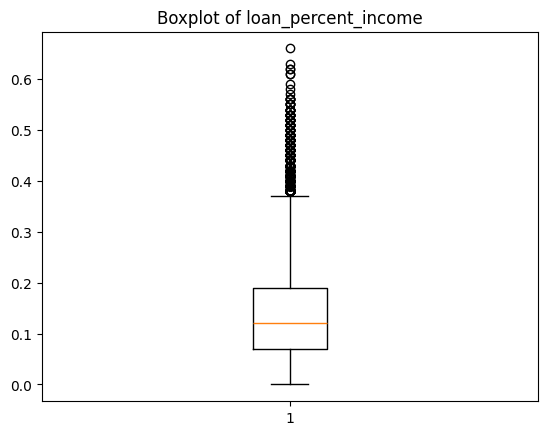

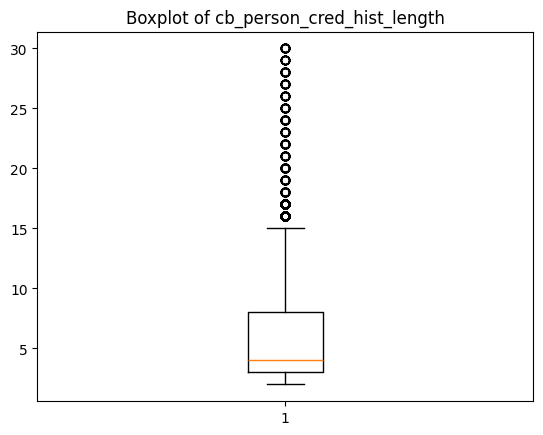

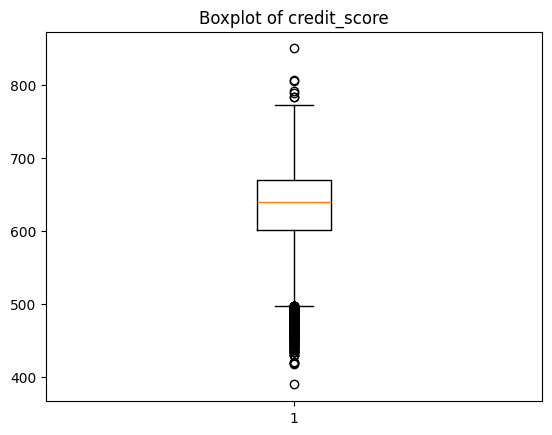

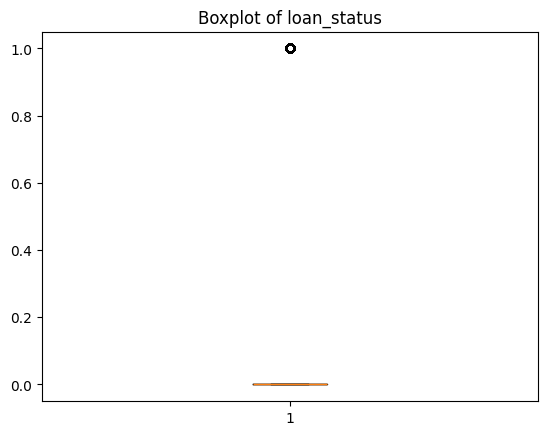

In [116]:
for col in numerical_cols:
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


**Insight:**  
The boxplots reveal several outliers in features like income and loan amount. These outliers suggest high variance in applicant financial profiles and justify the use of scaling and tree-based models, which are less sensitive to outliers.


Visualize categorical data

Bar charts:

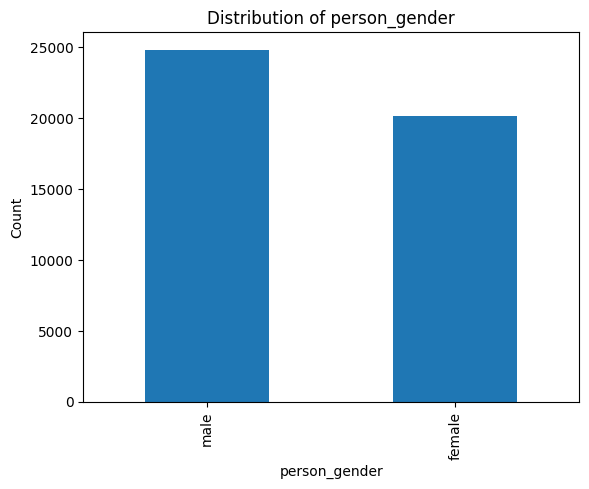

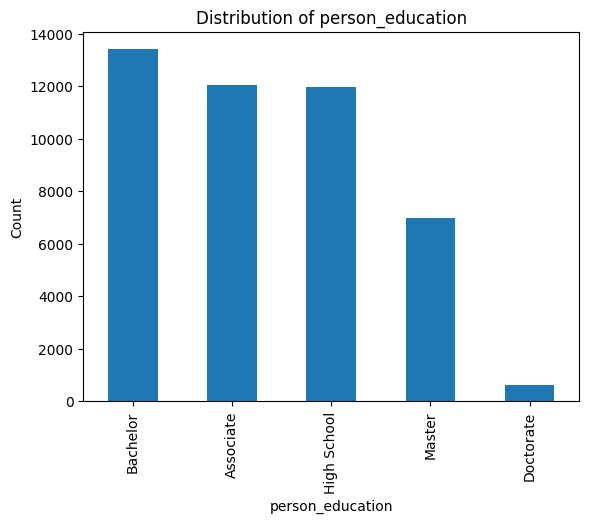

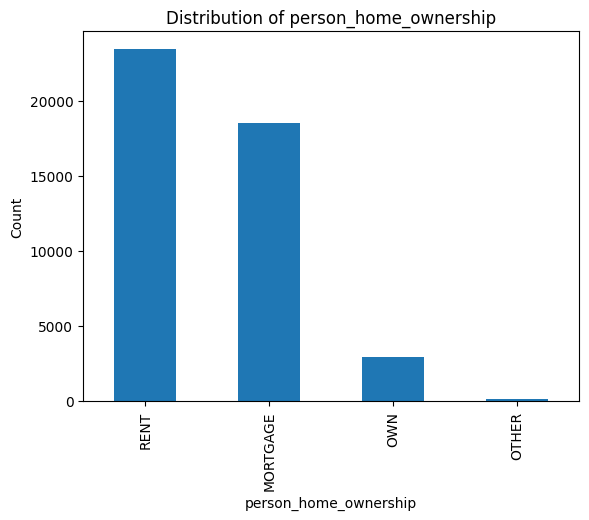

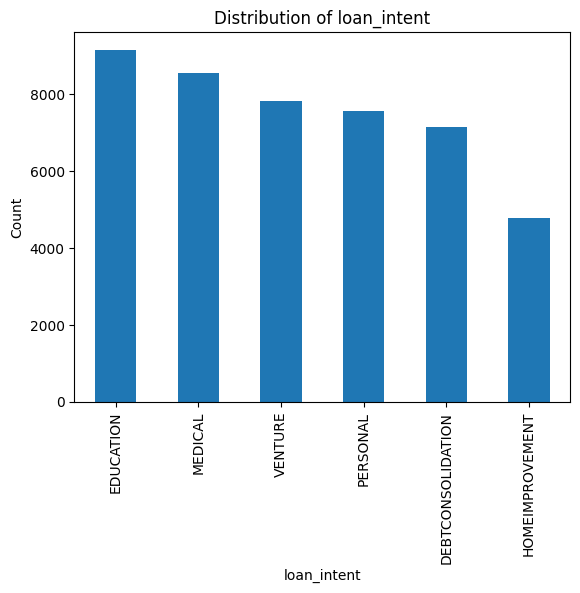

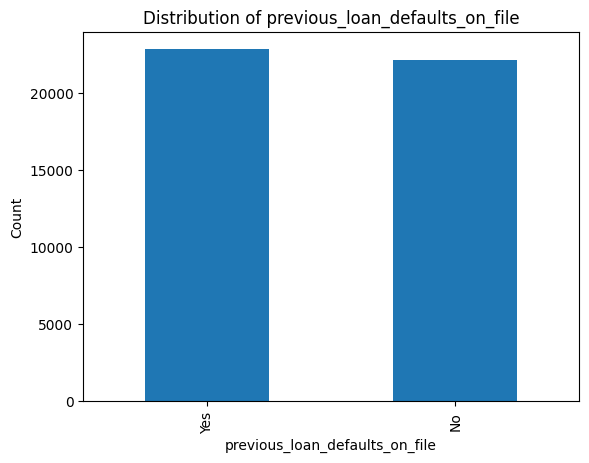

In [117]:
for col in categorical_cols:
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


**Insight:**  
The categorical plots show that features such as loan purpose and employment status have noticeable differences between approved and rejected loans. This indicates that categorical variables play an important role in predicting loan approval and should be properly encoded before modeling.


Relationship with target:

Numeric vs target

In [118]:
df.groupby(TARGET)[numerical_cols].mean()


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
loan_status,,,,,,,,,
0,27.833571,86157.040743,5.476714,9219.576914,10.477981,0.121783,5.898286,632.814914,0.0
1,27.521300,59886.096900,5.178000,10855.689800,12.856794,0.202521,5.759700,631.887200,1.0


Categorical vs target:

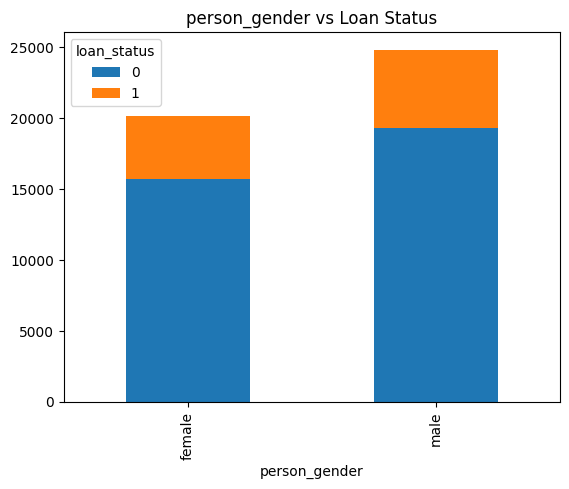

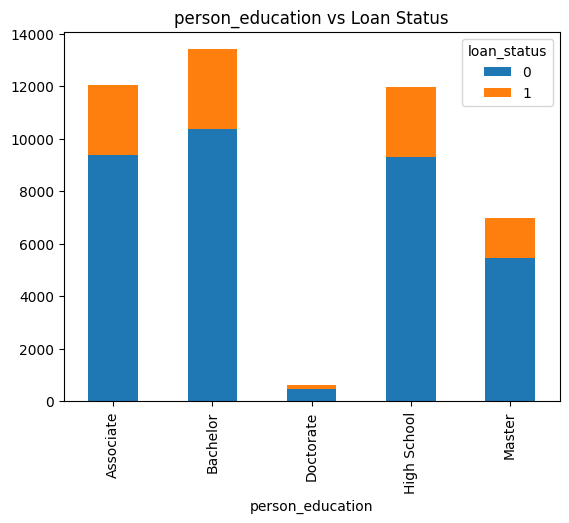

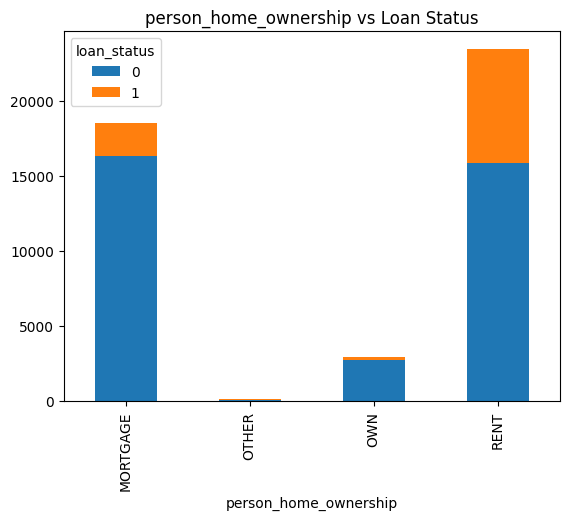

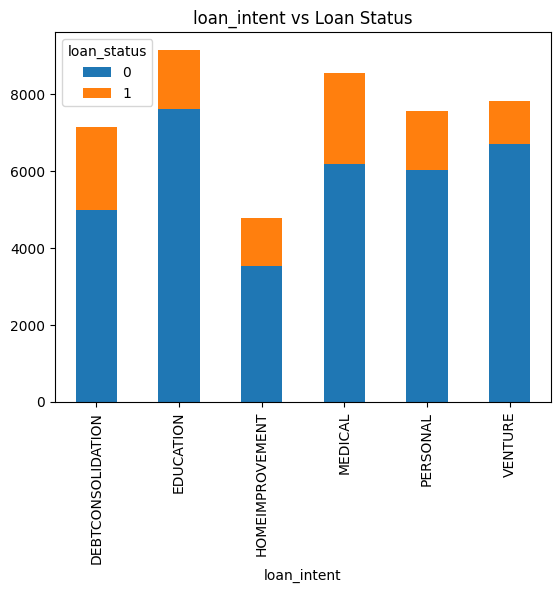

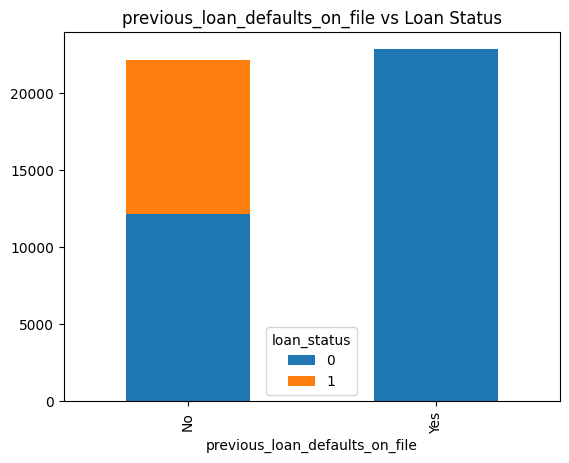

In [119]:
for col in categorical_cols:
    pd.crosstab(df[col], df[TARGET]).plot(kind="bar", stacked=True)
    plt.title(f"{col} vs Loan Status")
    plt.show()


**2. Build a Neural Network Model**

Imports (only for NN part)

In [121]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.utils.class_weight import compute_class_weight


Define X, y + split train/test

In [122]:
TARGET = "loan_status"

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts())


Train: (36000, 13) Test: (9000, 13)
Train class distribution:
 loan_status
0    28000
1     8000
Name: count, dtype: int64


Preprocessing (handle categorical + scale numeric)

In [123]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

print("Categorical:", cat_cols)
print("Numerical:", num_cols)


Categorical: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numerical: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


Define Neural Network (architecture + optimizer)

In [124]:
# Network architecture
HIDDEN_LAYERS = (64, 32)   # 2 hidden layers: 64 neurons then 32 neurons
ACTIVATION = "relu"        # activation function
OPTIMIZER = "adam"         # optimization algorithm (Adam)
ALPHA = 1e-4               # L2 regularization
LR = 1e-3                  # learning rate
EPOCHS = 500               # max_iter

print("Neural Network Architecture:")
print("Input ->", HIDDEN_LAYERS, "-> Output(1)")
print("Activation:", ACTIVATION)
print("Optimizer:", OPTIMIZER)
print("Loss: log_loss (handled internally by sklearn for classification)")

Neural Network Architecture:
Input -> (64, 32) -> Output(1)
Activation: relu
Optimizer: adam
Loss: log_loss (handled internally by sklearn for classification)


Train MLP (with class imbalance handling)

In [125]:
# Create sample weights for imbalance
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_map = {c: w for c, w in zip(classes, weights)}
sample_weight_train = y_train.map(class_weight_map).values

mlp_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=HIDDEN_LAYERS,
        activation=ACTIVATION,
        solver=OPTIMIZER,
        alpha=ALPHA,
        learning_rate_init=LR,
        max_iter=EPOCHS,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)
print("MLP training finished.")

MLP training finished.


Evaluate on Train + Test (required metrics)

In [126]:
def evaluate_nn(model, X_tr, y_tr, X_te, y_te):
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    print("\n=== TRAIN METRICS ===")
    print("Accuracy:", accuracy_score(y_tr, y_pred_tr))
    print("Precision:", precision_score(y_tr, y_pred_tr, zero_division=0))
    print("Recall:", recall_score(y_tr, y_pred_tr, zero_division=0))
    print("F1:", f1_score(y_tr, y_pred_tr, zero_division=0))

    print("\n=== TEST METRICS ===")
    print("Accuracy:", accuracy_score(y_te, y_pred_te))
    print("Precision:", precision_score(y_te, y_pred_te, zero_division=0))
    print("Recall:", recall_score(y_te, y_pred_te, zero_division=0))
    print("F1:", f1_score(y_te, y_pred_te, zero_division=0))

    print("\n--- Classification Report (TEST) ---")
    print(classification_report(y_te, y_pred_te, zero_division=0))

    print("--- Confusion Matrix (TEST) ---")
    print(confusion_matrix(y_te, y_pred_te))

evaluate_nn(mlp_model, X_train, y_train, X_test, y_test)



=== TRAIN METRICS ===
Accuracy: 0.9461111111111111
Precision: 0.9260404949381328
Recall: 0.82325
F1: 0.8716251985177342

=== TEST METRICS ===
Accuracy: 0.9091111111111111
Precision: 0.8312780269058296
Recall: 0.7415
F1: 0.7838266384778013

--- Classification Report (TEST) ---
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      7000
           1       0.83      0.74      0.78      2000

    accuracy                           0.91      9000
   macro avg       0.88      0.85      0.86      9000
weighted avg       0.91      0.91      0.91      9000

--- Confusion Matrix (TEST) ---
[[6699  301]
 [ 517 1483]]


**3. Build a Primary Model (Two Classical ML Models):**

Imports for classical models

In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


Evaluation function (same metrics as required)

In [128]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def evaluate_model(model, X_tr, y_tr, X_te, y_te, name="Model"):
    # Predictions
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    # Metrics (TRAIN)
    train_acc = accuracy_score(y_tr, y_pred_tr)
    train_prec = precision_score(y_tr, y_pred_tr, zero_division=0)
    train_rec = recall_score(y_tr, y_pred_tr, zero_division=0)
    train_f1 = f1_score(y_tr, y_pred_tr, zero_division=0)

    # Metrics (TEST)
    test_acc = accuracy_score(y_te, y_pred_te)
    test_prec = precision_score(y_te, y_pred_te, zero_division=0)
    test_rec = recall_score(y_te, y_pred_te, zero_division=0)
    test_f1 = f1_score(y_te, y_pred_te, zero_division=0)

    print(f"\n=== {name} (TRAIN) ===")
    print("Accuracy:", train_acc)
    print("Precision:", train_prec)
    print("Recall:", train_rec)
    print("F1:", train_f1)

    print(f"\n=== {name} (TEST) ===")
    print("Accuracy:", test_acc)
    print("Precision:", test_prec)
    print("Recall:", test_rec)
    print("F1:", test_f1)

    print("\n--- Classification Report (TEST) ---")
    print(classification_report(y_te, y_pred_te, zero_division=0))

    print("--- Confusion Matrix (TEST) ---")
    print(confusion_matrix(y_te, y_pred_te))

    return {
        "Model": name,
        "Train Accuracy": train_acc,
        "Train Precision": train_prec,
        "Train Recall": train_rec,
        "Train F1": train_f1,
        "Test Accuracy": test_acc,
        "Test Precision": test_prec,
        "Test Recall": test_rec,
        "Test F1": test_f1
    }


In [129]:
print("Training Logistic Regression...")

logreg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_model.fit(X_train, y_train)

print("Model trained. Evaluating now...")

logreg_results = evaluate_model(
    logreg_model,
    X_train, y_train,
    X_test, y_test,
    name="Logistic Regression"
)

print("Done.")



Training Logistic Regression...
Model trained. Evaluating now...

=== Logistic Regression (TRAIN) ===
Accuracy: 0.8565
Precision: 0.6191156691324815
Recall: 0.920625
F1: 0.7403498190591074

=== Logistic Regression (TEST) ===
Accuracy: 0.8598888888888889
Precision: 0.625723035045934
Recall: 0.9195
F1: 0.7446851589390565

--- Classification Report (TEST) ---
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      7000
           1       0.63      0.92      0.74      2000

    accuracy                           0.86      9000
   macro avg       0.80      0.88      0.82      9000
weighted avg       0.90      0.86      0.87      9000

--- Confusion Matrix (TEST) ---
[[5900 1100]
 [ 161 1839]]
Done.


Model 1: Logistic Regression (Baseline)

In [130]:
logreg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
])

logreg_model.fit(X_train, y_train)
logreg_results = evaluate_model(logreg_model, X_train, y_train, X_test, y_test, "Logistic Regression")



=== Logistic Regression (TRAIN) ===
Accuracy: 0.8565
Precision: 0.6191156691324815
Recall: 0.920625
F1: 0.7403498190591074

=== Logistic Regression (TEST) ===
Accuracy: 0.8598888888888889
Precision: 0.625723035045934
Recall: 0.9195
F1: 0.7446851589390565

--- Classification Report (TEST) ---
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      7000
           1       0.63      0.92      0.74      2000

    accuracy                           0.86      9000
   macro avg       0.80      0.88      0.82      9000
weighted avg       0.90      0.86      0.87      9000

--- Confusion Matrix (TEST) ---
[[5900 1100]
 [ 161 1839]]


Model 2: Decision Tree (Baseline)

In [131]:
dt_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

dt_model.fit(X_train, y_train)
dt_results = evaluate_model(dt_model, X_train, y_train, X_test, y_test, "Decision Tree")



=== Decision Tree (TRAIN) ===
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

=== Decision Tree (TEST) ===
Accuracy: 0.8992222222222223
Precision: 0.7690792712949286
Recall: 0.781
F1: 0.7749937980649962

--- Classification Report (TEST) ---
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      7000
           1       0.77      0.78      0.77      2000

    accuracy                           0.90      9000
   macro avg       0.85      0.86      0.86      9000
weighted avg       0.90      0.90      0.90      9000

--- Confusion Matrix (TEST) ---
[[6531  469]
 [ 438 1562]]


Compare and pick best model (required conclusion)

In [132]:
results_df = pd.DataFrame([logreg_results, dt_results])
display(results_df[["Model", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]])

best = results_df.sort_values("Test F1", ascending=False).iloc[0]
print("\n✅ Best model based on Test F1:", best["Model"])
print("Reason: Dataset is imbalanced, so F1 balances Precision and Recall better than Accuracy.")


,Model,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.859889,0.625723,0.9195,0.744685
1,Decision Tree,0.899222,0.769079,0.7810,0.774994



✅ Best model based on Test F1: Decision Tree
Reason: Dataset is imbalanced, so F1 balances Precision and Recall better than Accuracy.


**4. Hyper-parameter Optimization with Cross-Validation:**

Imports for Cross-Validation

In [133]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold


Cross-validation strategy:

In [134]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Using Stratified 5-Fold Cross Validation")


Using Stratified 5-Fold Cross Validation


Hyperparameters for Logistic Regression

In [135]:
logreg_tuned = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_logreg = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__solver": ["liblinear", "lbfgs"]
}


GridSearchCV for Logistic Regression

In [136]:
gs_logreg = GridSearchCV(
    estimator=logreg_tuned,
    param_grid=param_grid_logreg,
    scoring="f1",          # best metric for imbalanced data
    cv=cv,
    n_jobs=-1
)

gs_logreg.fit(X_train, y_train)

print("Best parameters (Logistic Regression):")
print(gs_logreg.best_params_)

print("\nBest cross-validation F1 score:")
print(gs_logreg.best_score_)


Best parameters (Logistic Regression):
{'clf__C': 10, 'clf__solver': 'lbfgs'}

Best cross-validation F1 score:
0.7405286836618553


Hyperparameters for Decision Tree

In [137]:
dt_tuned = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

param_grid_dt = {
    "clf__max_depth": [None, 5, 10, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 5]
}


GridSearchCV for Decision Tree

In [138]:
gs_dt = GridSearchCV(
    estimator=dt_tuned,
    param_grid=param_grid_dt,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

gs_dt.fit(X_train, y_train)

print("Best parameters (Decision Tree):")
print(gs_dt.best_params_)

print("\nBest cross-validation F1 score:")
print(gs_dt.best_score_)


Best parameters (Decision Tree):
{'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 2}

Best cross-validation F1 score:
0.7755700095185936


Summary of best hyperparameters (REQUIRED OUTPUT)

In [139]:
tuning_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Best Parameters": [gs_logreg.best_params_, gs_dt.best_params_],
    "Best CV F1 Score": [gs_logreg.best_score_, gs_dt.best_score_]
})

tuning_results


,Model,Best Parameters,Best CV F1 Score
0,Logistic Regression,"{'clf__C': 10, 'clf__solver': 'lbfgs'}",0.740529
1,Decision Tree,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.775570


**5. Feature Selection:**

Import feature selection tool

Justification:

I used Mutual Information (SelectKBest) as a filter-based method because it measures the dependency between each feature and the target and can capture non-linear relationships. It is computationally efficient and helps reduce dimensionality and overfitting. The selected features printed below are the top-k most informative features for predicting loan_status.

In [140]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif


In [148]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

fs_logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", SelectKBest(score_func=mutual_info_classif, k=20)),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42,
        C=gs_logreg.best_params_["clf__C"],
        solver=gs_logreg.best_params_["clf__solver"]
    ))
])

fs_dt = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", SelectKBest(score_func=mutual_info_classif, k=25)),
    ("clf", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=gs_dt.best_params_["clf__max_depth"],
        min_samples_split=gs_dt.best_params_["clf__min_samples_split"],
        min_samples_leaf=gs_dt.best_params_["clf__min_samples_leaf"]
    ))
])


Feature Selection + Logistic Regression (FINAL MODEL)

In [149]:
fs_logreg.fit(X_train, y_train)

# ===== PASTE FEATURE NAME CODE HERE =====
ohe = fs_logreg.named_steps["preprocess"] \
               .named_transformers_["cat"] \
               .named_steps["onehot"]

cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([num_cols, cat_feature_names])

mask = fs_logreg.named_steps["select"].get_support()
selected_features_logreg = all_feature_names[mask]

print("Selected features (Logistic Regression):")
print(selected_features_logreg)
# ===== END =====

logreg_fs_results = evaluate_model(
    fs_logreg,
    X_train, y_train,
    X_test, y_test,
    name="Logistic Regression + Feature Selection"
)


Selected features (Logistic Regression):
['person_age' 'person_income' 'loan_amnt' 'loan_int_rate'
 'loan_percent_income' 'cb_person_cred_hist_length' 'person_gender_female'
 'person_education_Associate' 'person_education_Bachelor'
 'person_education_High School' 'person_home_ownership_MORTGAGE'
 'person_home_ownership_OTHER' 'person_home_ownership_OWN'
 'person_home_ownership_RENT' 'loan_intent_DEBTCONSOLIDATION'
 'loan_intent_MEDICAL' 'loan_intent_PERSONAL' 'loan_intent_VENTURE'
 'previous_loan_defaults_on_file_No' 'previous_loan_defaults_on_file_Yes']

=== Logistic Regression + Feature Selection (TRAIN) ===
Accuracy: 0.8511388888888889
Precision: 0.6091412513430862
Recall: 0.92125
F1: 0.7333698193939997

=== Logistic Regression + Feature Selection (TEST) ===
Accuracy: 0.8488888888888889
Precision: 0.6057501652346332
Recall: 0.9165
F1: 0.7294070831675289

--- Classification Report (TEST) ---
              precision    recall  f1-score   support

           0       0.97      0.83     

Feature Selection + Decision Tree (FINAL MODEL)

In [142]:
fs_dt.fit(X_train, y_train)

# ===== PASTE FEATURE NAME CODE HERE =====
mask_dt = fs_dt.named_steps["select"].get_support()
selected_features_dt = all_feature_names[mask_dt]

print("\nSelected features (Decision Tree):")
print(selected_features_dt)
# ===== END =====

dt_fs_results = evaluate_model(
    fs_dt,
    X_train, y_train,
    X_test, y_test,
    name="Decision Tree + Feature Selection"
)



Selected features (Decision Tree):
['person_age' 'person_income' 'person_emp_exp' 'loan_amnt' 'loan_int_rate'
 'loan_percent_income' 'cb_person_cred_hist_length' 'credit_score'
 'person_gender_female' 'person_gender_male' 'person_education_Associate'
 'person_education_Bachelor' 'person_education_High School'
 'person_home_ownership_MORTGAGE' 'person_home_ownership_OTHER'
 'person_home_ownership_OWN' 'person_home_ownership_RENT'
 'loan_intent_DEBTCONSOLIDATION' 'loan_intent_EDUCATION'
 'loan_intent_HOMEIMPROVEMENT' 'loan_intent_MEDICAL'
 'loan_intent_PERSONAL' 'loan_intent_VENTURE'
 'previous_loan_defaults_on_file_No' 'previous_loan_defaults_on_file_Yes']

=== Decision Tree + Feature Selection (TRAIN) ===
Accuracy: 0.9533055555555555
Precision: 0.8395486297689414
Recall: 0.9765
F1: 0.9028604449581046

=== Decision Tree + Feature Selection (TEST) ===
Accuracy: 0.894
Precision: 0.7240788346186804
Recall: 0.845
F1: 0.7798800184586987

--- Classification Report (TEST) ---
              pr

Compare performance BEFORE vs AFTER feature selection

In [143]:
comparison = pd.DataFrame([
    logreg_results,
    logreg_fs_results,
    dt_results,
    dt_fs_results
])

comparison[[
    "Model",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1"
]]


,Model,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.859889,0.625723,0.9195,0.744685
1,Logistic Regression + Feature Selection,0.853222,0.612903,0.9215,0.736169
2,Decision Tree,0.899222,0.769079,0.7810,0.774994
3,Decision Tree + Feature Selection,0.894000,0.724079,0.8450,0.779880


Number of selected features(Optional)

In [144]:
print("Logistic Regression selected features:", 20)
print("Decision Tree selected features:", 25)


Logistic Regression selected features: 20
Decision Tree selected features: 25


**6. Final Models and Comparative Analysis**

Re-confirm final evaluation

In [145]:
final_logreg_results = evaluate_model(
    fs_logreg,
    X_train, y_train,
    X_test, y_test,
    name="Final Logistic Regression"
)

final_dt_results = evaluate_model(
    fs_dt,
    X_train, y_train,
    X_test, y_test,
    name="Final Decision Tree"
)



=== Final Logistic Regression (TRAIN) ===
Accuracy: 0.8518333333333333
Precision: 0.6104574080212132
Recall: 0.920875
F1: 0.7342037073948575

=== Final Logistic Regression (TEST) ===
Accuracy: 0.8532222222222222
Precision: 0.6129032258064516
Recall: 0.9215
F1: 0.7361693628919512

--- Classification Report (TEST) ---
              precision    recall  f1-score   support

           0       0.97      0.83      0.90      7000
           1       0.61      0.92      0.74      2000

    accuracy                           0.85      9000
   macro avg       0.79      0.88      0.82      9000
weighted avg       0.89      0.85      0.86      9000

--- Confusion Matrix (TEST) ---
[[5836 1164]
 [ 157 1843]]

=== Final Decision Tree (TRAIN) ===
Accuracy: 0.9533055555555555
Precision: 0.8395486297689414
Recall: 0.9765
F1: 0.9028604449581046

=== Final Decision Tree (TEST) ===
Accuracy: 0.894
Precision: 0.7240788346186804
Recall: 0.845
F1: 0.7798800184586987

--- Classification Report (TEST) ---
    

Build Table  (Final Classification Comparison Table)

In [146]:
table4 = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Features": "Selected (k=20)",
        "CV Score": gs_logreg.best_score_,
        "Accuracy": final_logreg_results["Test Accuracy"],
        "Precision": final_logreg_results["Test Precision"],
        "Recall": final_logreg_results["Test Recall"],
        "F1-Score": final_logreg_results["Test F1"]
    },
    {
        "Model": "Decision Tree",
        "Features": "Selected (k=25)",
        "CV Score": gs_dt.best_score_,
        "Accuracy": final_dt_results["Test Accuracy"],
        "Precision": final_dt_results["Test Precision"],
        "Recall": final_dt_results["Test Recall"],
        "F1-Score": final_dt_results["Test F1"]
    }
])

table4


,Model,Features,CV Score,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,Selected (k=20),0.740529,0.853222,0.612903,0.9215,0.736169
1,Decision Tree,Selected (k=25),0.775570,0.894000,0.724079,0.8450,0.779880


Pick the best final model (required conclusion)

In [147]:
best_final = table4.sort_values("F1-Score", ascending=False).iloc[0]

print("✅ Best final model:", best_final["Model"])
print("Reason: Dataset is imbalanced, so F1-score is the fairest metric to compare performance.")


✅ Best final model: Decision Tree
Reason: Dataset is imbalanced, so F1-score is the fairest metric to compare performance.
